# 🧠 SomaTrack — Predicting Study-Related Physical Ailments
**ENSIA Machine Learning Project · Spring 2025-2026**

For this project, we collected survey data from students at ENSIA to understand how their study habits affect their physical health — specifically back pain, neck pain, and headaches. The goal is to build a machine learning model that can predict whether a student is at **no, mild, frequent, or chronic** pain risk based on how they study.

This notebook covers the full ML pipeline, from loading and cleaning the data to training and evaluating our model.

## Table of Contents
1. [Imports & Setup](#1)
2. [Data Loading & Feature Engineering](#2)
3. [Stratified Train / Test Split](#3)
4. [Pipeline Definition](#4)
5. [Cross-Validation Baseline](#5)
6. [Hyperparameter Tuning — RandomizedSearchCV](#6)
7. [Final Evaluation on Test Set](#7)
8. [Train vs Test Performance Comparison](#8)
9. [Bonus — SMOTE vs No-SMOTE Comparison](#9)


### what i did in brief:

- I extracted the target `pain_level` and converted it to 0–3 classes (No, Mild, Frequent, Chronic).
- I parsed the sub-pain questions (back, neck, headache, etc.) into numeric columns.
- I turned ordered survey answers into numbers (ordinal encoding) and converted ranges to midpoints for water/sleep.
- I created new features like `sitting_load` (hours × days) and `break_quality` (combined break scores).
- I one-hot encoded purely nominal fields (e.g., study location) and turned pre-existing conditions into binary flags.
- I dropped demographics and redundant raw columns to focus on habit-based predictors.
- I split the data stratified 80/20 (train/test) so class proportions stay the same.
- I built an `ImbPipeline` with median imputation, `StandardScaler`, `SelectKBest` (mutual info), `BorderlineSMOTE`, and a `RandomForestClassifier`.
- I ran stratified 5‑fold cross-validation to get a baseline (reporting train and validation scores).
- I used `RandomizedSearchCV` (30 trials) to tune `selector__k`, `clf__max_depth`, and `clf__min_samples_leaf`, optimizing F1‑macro.
- I evaluated the best tuned pipeline on the held‑out test set and plotted the confusion matrix.
- I inspected and saved the top selected features (saved to CSV) to identify actionable risk factors.
- I compared pipelines with and without SMOTE (CV + test) to see whether SMOTE helps.


## 1. Imports & Setup <a id="1"></a>

We start by importing everything we need. The most important one here is `ImbPipeline` from `imblearn.pipeline` — this is **not** the same as sklearn's regular `Pipeline`. The difference matters because SMOTE uses a `fit_resample()` method instead of `fit_transform()`, and sklearn's Pipeline doesn't know how to handle that. `ImbPipeline` does.

We also set `SEED = 42` everywhere so our results are reproducible — meaning if someone else runs this notebook, they should get the same numbers we did.


In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

# ── Data ──────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn: model selection ─────────────────────────────────────────────
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    RandomizedSearchCV,
    train_test_split,
)

# ── Scikit-learn: preprocessing ───────────────────────────────────────────────
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ── Scikit-learn: feature selection ───────────────────────────────────────────
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# ── Scikit-learn: models & metrics ────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
)

# ── Imbalanced-learn: ImbPipeline + SMOTE ────────────────────────────────────
# ImbPipeline is the correct pipeline class when SMOTE is one of the steps.
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import BorderlineSMOTE

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi":    120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

print("All imports successful.")

All imports successful.


## 2. Data Loading & Feature Engineering <a id="2"></a>

Here we load the raw survey responses. The survey had 34 columns — a mix of numerical answers (like hours of sitting) and text-based ordinal answers (like "Never / Rarely / Often").

Feature engineering at this stage is fine and does **not** cause leakage, because we're only applying domain knowledge to transform the raw text into numbers. We're not computing any statistics (like means or medians) from the data — we're just encoding what we already know from the survey design (e.g., "Never" = 0, "Rarely" = 1, etc.).

Steps that *do* compute statistics — like filling missing values, scaling, or selecting features — are kept inside the pipeline for exactly this reason.


In [2]:
# ── Load ──────────────────────────────────────────────────────────────────────
df_raw = pd.read_csv("/home/asmaa/Documents/3rd year/2nd semester/ML/project/SomaTrack---Predicting-Study-Related-Physical-Ailments-ML-based-System/data/SomaTrack_—_Study_Habits_&_Physical_Health_Survey_Responses_Form.csv")

RENAME = {
    df_raw.columns[0]:  "timestamp",
    df_raw.columns[1]:  "sitting_hours",
    df_raw.columns[2]:  "study_days",
    df_raw.columns[3]:  "max_continuous_sitting",
    df_raw.columns[4]:  "break_freq",
    df_raw.columns[5]:  "break_duration",
    df_raw.columns[6]:  "break_movement",
    df_raw.columns[7]:  "water_intake",
    df_raw.columns[8]:  "caffeine_freq",
    df_raw.columns[9]:  "screen_hours",
    df_raw.columns[10]: "stress_level",
    df_raw.columns[11]: "study_location",
    df_raw.columns[12]: "seat_type",
    df_raw.columns[13]: "input_device",
    df_raw.columns[14]: "posture",
    df_raw.columns[15]: "back_support",
    df_raw.columns[16]: "screen_eye_level",
    df_raw.columns[17]: "pre_existing",
    df_raw.columns[18]: "backpack_weight",
    df_raw.columns[19]: "lighting",
    df_raw.columns[20]: "exercise_freq",
    df_raw.columns[21]: "sleep_duration",
    df_raw.columns[22]: "back_pain",
    df_raw.columns[23]: "neck_pain",
    df_raw.columns[24]: "headache",
    df_raw.columns[25]: "wrist_pain",
    df_raw.columns[26]: "eye_strain",
    df_raw.columns[27]: "finger_numb",
    df_raw.columns[28]: "pain_level",
    df_raw.columns[29]: "age",
    df_raw.columns[30]: "gender",
    df_raw.columns[31]: "institution",
    df_raw.columns[32]: "field",
    df_raw.columns[33]: "year_of_study",
}
df = df_raw.rename(columns=RENAME).copy()
print(f"Raw data: {df.shape[0]} rows, {df.shape[1]} columns")

Raw data: 270 rows, 34 columns


### 2.1 Extracting the Target Variable

The pain level in our survey was stored as a string like `"2 — Frequent / regular pain"`. We extract just the leading digit (0, 1, 2, or 3) and convert it to an integer.

Our target has **4 classes**:
- `0` → No pain
- `1` → Mild / occasional pain
- `2` → Frequent / regular pain
- `3` → Chronic pain

**Why this matters for the model:** Having 4 classes instead of 2 (pain / no pain) gives us more detail, but it also makes the task harder — especially when some classes have very few samples.


In [3]:
TARGET = "pain_level"
df[TARGET] = df[TARGET].str[0].astype(int)

print("Target distribution:")
print(
    df[TARGET]
    .value_counts()
    .sort_index()
    .rename({0: "0-No pain", 1: "1-Mild", 2: "2-Frequent", 3: "3-Chronic"})
)

Target distribution:
pain_level
0-No pain      16
1-Mild        123
2-Frequent    105
3-Chronic      26
Name: count, dtype: int64


### 2.2 Ordinal Encoding

Many of our survey features have a natural order — for example, "Never < Rarely < Every 1-2 hours < Every 30-60 minutes". For these, we use **ordinal encoding**, which assigns increasing integers that respect that order.

We did **not** use one-hot encoding here because it would treat these categories as if they have no order, which would throw away useful information. For example, one-hot encoding would make "Never" and "Rarely" look equally different from "Often", when in reality they're on a continuous scale.

For `water_intake` and `sleep_duration`, we used midpoint values (e.g., "1-1.5L" → 1.25L) to keep the numerical meaning more realistic.


In [4]:
# ── Sub-pain columns: extract leading digit ───────────────────────────────────
PAIN_COLS = ["back_pain", "neck_pain", "headache", "wrist_pain", "eye_strain", "finger_numb"]
for col in PAIN_COLS:
    df[col] = df[col].str[0].astype(int)

# ── Ordinal maps ──────────────────────────────────────────────────────────────
ordinal_maps = {
    "break_freq": {
        "Never": 0, "Rarely": 1, "Every 1-2 hours": 2, "Every 30-60 minutes": 3,
    },
    "break_duration": {
        "I don't take breaks": 0, "Less than 5 minutes": 1,
        "5 - 10 minutes": 2, "10 - 30 minutes": 3, "More than 30 minutes": 4,
    },
    "break_movement": {
        "I don't take breaks": 0, "No, I stay seated": 1, "Sometimes": 2,
        "Yes, I walk or move around or just lie down on a bed or sofa": 3,
    },
    "water_intake": {
        "Less than 1L": 0.75, "1-1.5L": 1.25, "1.5-2L": 1.75, "More than 2L": 2.25,
    },
    "caffeine_freq": {
        "Never": 0, "1–2 times per week": 1, "3–5 times per week": 2,
        "1 drink per day": 3, "+2 drinks per day": 4,
    },
    "stress_level":    {"Low": 0, "Moderate": 1, "High": 2},
    "posture": {
        "Upright / straight back": 0, "Slightly slouched": 1,
        "Heavily slouched / hunched": 2, "Lying down": 3,
    },
    "back_support":    {"Yes": 0, "Sometimes": 1, "No": 2},
    "screen_eye_level": {
        "Yes, always": 0, "Sometimes": 1,
        "No, I look down at it most of the time": 2,
    },
    "backpack_weight": {
        "I rarely carry a backpack": 0, "Less than 3 kg": 1,
        "3–5 kg": 2, "5–8 kg": 3, "More than 8 kg": 4,
    },
    "exercise_freq": {"No": 0, "1 – 2 times": 1, "3 – 4 times": 2, "+5 times": 3},
    "sleep_duration": {
        "Less than 5h": 4.5, "5 – 6h": 5.5, "6 – 7h": 6.5,
        "7 – 8h": 7.5, "More than 8h": 8.5,
    },
}

for col, mapping in ordinal_maps.items():
    df[col] = df[col].map(mapping)
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Ordinal encoding complete.")

Ordinal encoding complete.


### 2.3 Creating New Features (Feature Engineering)

Beyond the raw columns, we created some new features that we thought would better capture the underlying risk:

- **`sitting_load`** = `sitting_hours × study_days` — captures the *total weekly sitting exposure*, which is more informative than daily hours alone. We capped it at 112 (the max possible in a week).
- **`break_quality`** = sum of `break_freq + break_duration + break_movement` — a single score that reflects how well a student recovers during breaks.
- **Pre-existing condition flags** — instead of storing conditions as a single text field, we split them into 4 binary columns (`cond_back`, `cond_neck`, `cond_wrist`, `cond_shoulder`).

We also one-hot encoded the purely nominal columns `study_location` and `seat_type`, since these have no meaningful order (a Café isn't "more" than a Library in any numerical sense).

Finally, we dropped demographic columns (age, gender, institution, field, year) since our goal is to identify *habit-based* risk factors — not to profile students by who they are.


In [5]:
# ── Pre-existing conditions → 4 binary flags ─────────────────────────────────
def parse_conditions(val):
    val = str(val).lower()
    return {
        "cond_back":     int("back"     in val),
        "cond_neck":     int("neck"     in val),
        "cond_wrist":    int("wrist"    in val),
        "cond_shoulder": int("shoulder" in val),
    }

cond_df = df["pre_existing"].apply(parse_conditions).apply(pd.Series)
df = pd.concat([df.drop(columns=["pre_existing"]), cond_df], axis=1)

# ── Binary flags ──────────────────────────────────────────────────────────────
df["has_external_mouse"] = df["input_device"].apply(
    lambda x: 1 if "external mouse" in str(x).lower()
                or "keyboard + mouse" in str(x).lower() else 0
)
df["is_dim_lighting"] = (df["lighting"] == "Dim lighting").astype(int)

# ── One-hot encode nominal categoricals ───────────────────────────────────────
df = pd.get_dummies(df, columns=["study_location"], prefix="loc")
df = pd.get_dummies(df, columns=["seat_type"],      prefix="seat")

# ── Composite features ────────────────────────────────────────────────────────
df["sitting_load"]   = (df["sitting_hours"] * df["study_days"]).clip(upper=112)
df["break_quality"]  = (
    df["break_freq"].fillna(0)
    + df["break_duration"].fillna(0)
    + df["break_movement"].fillna(0)
)
df["ergonomic_risk"] = (
    df["posture"].fillna(1)
    + df["screen_eye_level"].fillna(1)
    + df["back_support"].fillna(1)
)

# ── Drop demographics and raw columns already distilled into flags ─────────────
# ── Composite features ────────────────────────────────────────────────────────
df["sitting_load"]  = (df["sitting_hours"] * df["study_days"]).clip(upper=112)
df["break_quality"] = (
    df["break_freq"].fillna(0)
    + df["break_duration"].fillna(0)
    + df["break_movement"].fillna(0)
)
# ergonomic_risk removed — posture, screen_eye_level, back_support stay as
# individual features and the model learns their relationship itself

# ── Drop demographics, raw columns distilled into flags, and replaced originals
DROP_COLS = [
    "timestamp", "age", "gender", "institution",
    "field", "year_of_study", "input_device", "lighting",
    "sitting_hours", "study_days",          # replaced by sitting_load
    "break_freq", "break_duration", "break_movement",  # replaced by break_quality
]
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

# ── Build X and y ─────────────────────────────────────────────────────────────
# Cast all bool columns from get_dummies to int (required for sklearn)
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

X = df.drop(columns=[TARGET]).astype(float)
y = df[TARGET]

print(f"Feature matrix : {X.shape[1]} features | {X.shape[0]} samples")
print(f"Missing values : {X.isnull().sum().sum()}")
print(f"Target classes : {sorted(y.unique())}")

Feature matrix : 38 features | 270 samples
Missing values : 3
Target classes : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


### 2.4 Visualizing the Data

Before modeling, we plotted two important things:

**1. Class balance:** We expected — and confirmed — that our dataset is heavily imbalanced. Most students reported Frequent or Mild pain, while very few reported No pain or Chronic pain. This is a real problem for ML models: if the model just predicts "Frequent" every time, it would still get a decent accuracy, but it would completely miss the students with Chronic pain who probably need the most attention.

**2. Feature correlation heatmap:** We used a Pearson correlation matrix to see which features are related to each other. Features that are highly correlated with each other (but not with the target) can add noise. This also helped us later justify using `SelectKBest` to drop redundant features.


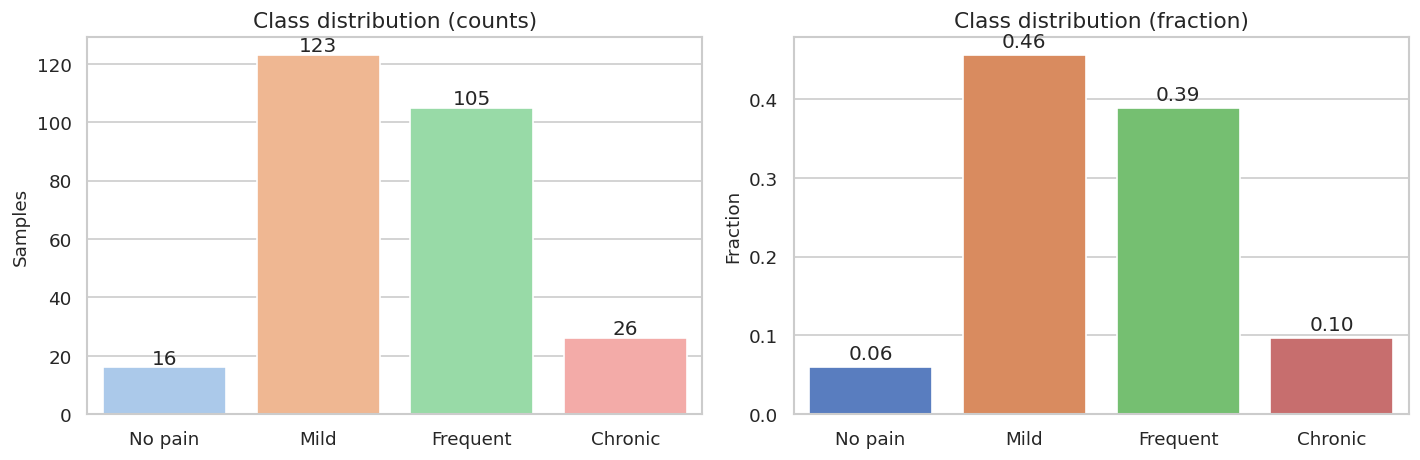

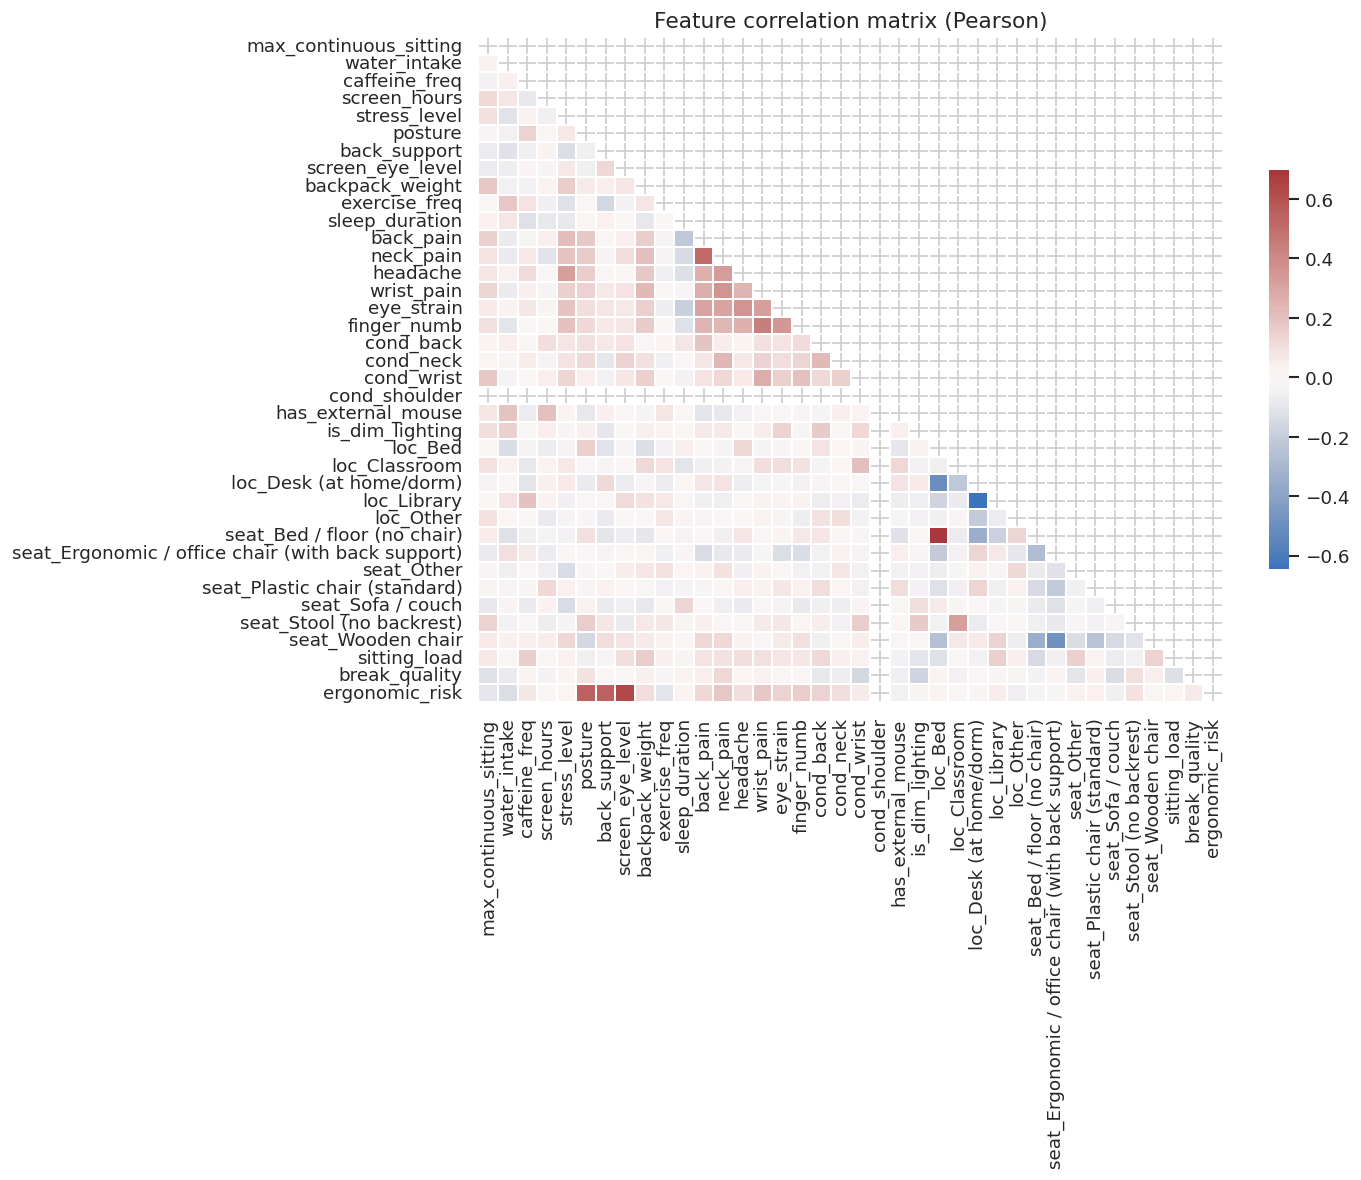

38


In [6]:
# ── Plots: class balance and feature correlation ─────────────────────────────
import matplotlib.pyplot as plt

# Class balance: counts and fraction
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = y.value_counts().sort_index()
label_map = {0: "No pain", 1: "Mild", 2: "Frequent", 3: "Chronic"}
labels = [label_map[i] for i in counts.index]
sns.barplot(x=labels, y=counts.values, palette="pastel", ax=axes[0])
axes[0].set_title("Class distribution (counts)")
axes[0].set_ylabel("Samples")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + max(counts.values) * 0.01, str(v), ha="center")

percent = counts / counts.sum()
sns.barplot(x=labels, y=percent.values, palette="muted", ax=axes[1])
axes[1].set_title("Class distribution (fraction)")
axes[1].set_ylabel("Fraction")
for i, v in enumerate(percent.values):
    axes[1].text(i, v + 0.01, f"{v:.2f}", ha="center")

plt.tight_layout()
plt.savefig("class_balance.png", dpi=120, bbox_inches="tight")
plt.show()

# Correlation matrix between features
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12, 10))
sns.heatmap(corr, mask=mask, cmap="vlag", center=0, linewidths=0.25, cbar_kws={"shrink": 0.6})
plt.title("Feature correlation matrix (Pearson)")
plt.tight_layout()
plt.savefig("feature_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

print(X.shape[1])

## 3. Stratified Train / Test Split <a id="3"></a>

We split our data **once** into 80% training and 20% test before doing anything else. The test set is then completely locked away — we don't touch it again until the very end (Section 7).

We used **stratified splitting** to make sure each pain level is proportionally represented in both sets. This is crucial because our "No pain" class only has about 14 students total — without stratification, we might end up with 0 of them in the test set.

**Why split before cross-validation?** Cross-validation is done on the training set only. The test set acts as our final "real world" simulation — data the model has genuinely never seen.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

print(f"Train : {X_train.shape[0]} samples | Test : {X_test.shape[0]} samples")
print("\nClass distribution — train:")
print(
    y_train.value_counts().sort_index()
    .rename({0: "No pain", 1: "Mild", 2: "Frequent", 3: "Chronic"})
)
print("\nClass distribution — test:")
print(
    y_test.value_counts().sort_index()
    .rename({0: "No pain", 1: "Mild", 2: "Frequent", 3: "Chronic"})
)

Train : 216 samples | Test : 54 samples

Class distribution — train:
pain_level
No pain     13
Mild        98
Frequent    84
Chronic     21
Name: count, dtype: int64

Class distribution — test:
pain_level
No pain      3
Mild        25
Frequent    21
Chronic      5
Name: count, dtype: int64


## 4. Pipeline Definition <a id="4"></a>

This is the heart of our approach. Everything that needs to "learn" from data is placed inside an `ImbPipeline`:

```
ImbPipeline
│
├── imputer    → fills missing values using the median of the training fold
├── scaler     → standardizes features (mean=0, std=1) so they're on the same scale
├── selector   → keeps the top k features most relevant to pain level (mutual information)
├── smote      → generates synthetic samples for minority classes (only in training folds)
└── clf        → Random Forest classifier with class_weight="balanced"
```

**Why `k_neighbors=3` in SMOTE?**
Our "No pain" class has only ~11 samples in the training fold during cross-validation. SMOTE's default is `k_neighbors=5`, which requires at least 6 samples in the minority class — we would get an error. Using `k_neighbors=3` keeps it working while still generating meaningful synthetic samples.

**Why Random Forest?** It handles mixed feature types well, is robust to outliers (common in self-reported survey data), and gives us feature importance scores we can interpret — which is important for the "explainability" requirement of the project.


In [8]:
def build_pipeline(k: int = 20, max_depth: int = None,
                   min_samples_leaf: int = 1,
                   with_smote: bool = True) -> ImbPipeline:
    """
    Build a fully encapsulated ImbPipeline.

    Parameters
    ----------
    k                : number of features for SelectKBest
    max_depth        : RandomForest max_depth (None = unlimited)
    min_samples_leaf : RandomForest min_samples_leaf
    with_smote       : whether to include BorderlineSMOTE (for SMOTE vs no-SMOTE comparison)

    Returns
    -------
    ImbPipeline ready for cross_validate or fit()
    """
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("selector", SelectKBest(score_func=mutual_info_classif, k=k)),
    ]

    if with_smote:
        steps.append((
            "smote",
            BorderlineSMOTE(
                sampling_strategy="not majority",
                kind="borderline-1",
                k_neighbors=3,        # safe for small minority classes
                random_state=SEED,
            ),
        ))

    steps.append((
        "clf",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
        ),
    ))

    return ImbPipeline(steps=steps)


# Default pipeline used for baseline CV
pipeline = build_pipeline(k=20, max_depth=None, min_samples_leaf=1, with_smote=True)
print("Pipeline built:")
for name, step in pipeline.steps:
    print(f"  {name:12s} → {step.__class__.__name__}")

Pipeline built:
  imputer      → SimpleImputer
  scaler       → StandardScaler
  selector     → SelectKBest
  smote        → BorderlineSMOTE
  clf          → RandomForestClassifier


## 5. Cross-Validation Baseline <a id="5"></a>

We used **Stratified 5-Fold Cross-Validation** on the training set. This means we split the training data into 5 chunks, train on 4 of them, validate on the 5th, and repeat 5 times — each fold gets to be the validation set once.

Here's what happens inside each fold, in order:
1. The imputer computes medians **from training rows only**
2. The scaler computes mean/std **from training rows only**
3. SelectKBest scores features **from training rows only**
4. SMOTE generates synthetic samples **from training rows only**
5. Random Forest trains on the result
6. The validation fold is transformed (not fitted) and predictions are scored

**Why do we report both train and validation scores?** If the training score is much higher than the validation score, that's a sign of overfitting — the model memorized the training data instead of learning general patterns. We want both scores to be close to each other.

We tracked three metrics:
- **F1-macro**: treats all 4 classes equally — best for imbalanced data
- **F1-weighted**: weights by class size — tells us overall quality
- **Accuracy**: simple percentage correct — can be misleading with imbalanced data


In [9]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

SCORING = ["f1_macro", "f1_weighted", "accuracy"]

baseline_results = cross_validate(
    pipeline,
    X_train, y_train,
    cv=CV,
    scoring=SCORING,
    return_train_score=True,  # included to surface overfitting if present
    n_jobs=-1,
)

print("=" * 55)
print("BASELINE CROSS-VALIDATION RESULTS  (5-fold, training set)")
print("=" * 55)
for metric in SCORING:
    val_scores   = baseline_results[f"test_{metric}"]
    train_scores = baseline_results[f"train_{metric}"]
    print(
        f"  {metric:15s}  "
        f"val  {val_scores.mean():.3f} ± {val_scores.std():.3f}  |  "
        f"train {train_scores.mean():.3f} ± {train_scores.std():.3f}"
    )

BASELINE CROSS-VALIDATION RESULTS  (5-fold, training set)
  f1_macro         val  0.469 ± 0.139  |  train 1.000 ± 0.000
  f1_weighted      val  0.559 ± 0.097  |  train 1.000 ± 0.000
  accuracy         val  0.574 ± 0.093  |  train 1.000 ± 0.000


## 6. Hyperparameter Tuning — RandomizedSearchCV <a id="6"></a>

Instead of guessing the best settings for our model, we use `RandomizedSearchCV` to try 30 random combinations of hyperparameters and pick the best one based on **F1-macro** score.

The parameters we tuned:
- **`selector__k`**: how many features to keep — too few and we lose information, too many and we add noise
- **`clf__max_depth`**: how deep the decision trees can grow — deeper = more complex = more likely to overfit
- **`clf__min_samples_leaf`**: minimum number of samples at each leaf — higher = more regularized, less likely to overfit

We used `scoring="f1_macro"` because our dataset is imbalanced. Accuracy would favor the majority class (Frequent pain) and we'd never optimize for detecting Chronic pain — which is the most medically important category.

`refit=True` means that after finding the best hyperparameters, sklearn automatically retrains the model on the *full training set* using those parameters — so `search.best_estimator_` is ready to use right away.


In [10]:
from scipy.stats import randint

# Estimate how many features have non-zero mutual information on the training set.
# This uses only X_train/y_train, so it stays inside the tuning stage and does not
# look at the held-out test set.
mi_imputer = SimpleImputer(strategy="median")
mi_scaler = StandardScaler()
X_train_mi = mi_imputer.fit_transform(X_train)
X_train_mi = mi_scaler.fit_transform(X_train_mi)
mi_scores = mutual_info_classif(X_train_mi, y_train, random_state=SEED)
max_k = int((mi_scores > 0).sum())
max_k = max(10, max_k)  # keep the lower bound sensible even if MI is sparse

print(f"Non-zero mutual information features: {max_k}")

# Hyperparameter search space
PARAM_DIST = {
    "selector__k":              randint(10, max_k + 1),
    "clf__max_depth":           [None, 4, 6, 8, 10, 12],
    "clf__min_samples_leaf":    randint(1, 8),
}

search_pipeline = build_pipeline(with_smote=True)   # fresh pipeline for search

search = RandomizedSearchCV(
    estimator=search_pipeline,
    param_distributions=PARAM_DIST,
    n_iter=30,              # 30 random combinations
    scoring="f1_macro",     # optimise for macro F1 (handles class imbalance)
    cv=CV,
    random_state=SEED,
    n_jobs=-1,
    refit=True,             # refit best params on full X_train after search
    verbose=0,
    return_train_score=True,
)

print("Running RandomizedSearchCV (30 iterations × 5 folds = 150 fits)...")
search.fit(X_train, y_train)

print(f"\nBest CV F1-macro : {search.best_score_:.3f}")
print("Best parameters  :")
for param, value in search.best_params_.items():
    print(f"  {param:30s} = {value}")


Non-zero mutual information features: 21
Running RandomizedSearchCV (30 iterations × 5 folds = 150 fits)...

Best CV F1-macro : 0.493
Best parameters  :
  clf__max_depth                 = 8
  clf__min_samples_leaf          = 5
  selector__k                    = 20


In [11]:
# Visualise top 10 hyperparameter combinations
results_df = pd.DataFrame(search.cv_results_)
top10 = (
    results_df
    .sort_values("mean_test_score", ascending=False)
    .head(10)[["param_selector__k", "param_clf__max_depth",
               "param_clf__min_samples_leaf",
               "mean_test_score", "std_test_score",
               "mean_train_score"]]
    .reset_index(drop=True)
)
top10.columns = ["k", "max_depth", "min_leaf", "val F1-macro", "val std", "train F1-macro"]
print("Top 10 combinations:")
print(top10.round(3).to_string(index=False))

Top 10 combinations:
 k max_depth  min_leaf  val F1-macro  val std  train F1-macro
20         8         5         0.493    0.159           0.804
21        12         5         0.471    0.114           0.793
21         8         7         0.468    0.050           0.731
14         4         4         0.463    0.118           0.713
21         4         4         0.458    0.084           0.736
13         8         7         0.456    0.043           0.691
14      None         3         0.454    0.099           0.828
15        12         6         0.448    0.131           0.749
14         6         7         0.447    0.120           0.675
16         4         3         0.429    0.127           0.717


## 7. Final Evaluation on the Test Set <a id="7"></a>

This is the only place in the notebook where we use the test set. We take the best pipeline found by `RandomizedSearchCV` (which was already refitted on the full training set) and evaluate it on the 20% of data we set aside at the beginning.

**How to read the classification report:**
- **Precision**: out of all students the model predicted as "Chronic", what fraction actually were? (avoids false alarms)
- **Recall**: out of all students who actually have Chronic pain, what fraction did the model catch? (avoids missing real cases)
- **F1-score**: the harmonic mean of precision and recall — a balanced measure
- **Support**: how many real samples exist in each class

The confusion matrix shows us exactly where the model gets confused — for example, whether it tends to confuse "Frequent" with "Chronic", which would be a medically significant error.

**What the selected features tell us:** The `SelectKBest` step tells us which features were most predictive of pain level according to mutual information. These are the habits and environmental factors that matter most — directly useful for the project's practical goal of identifying risk factors.


In [12]:
best_pipeline = search.best_estimator_   # already fitted on full X_train

# Predict on the held-out test set
y_pred = best_pipeline.predict(X_test)

print("=" * 55)
print(f"BEST MODEL TEST SET REPORT — {search.best_params_}")
print("=" * 55)
print(classification_report(
    y_test, y_pred,
    target_names=["0-No pain", "1-Mild", "2-Frequent", "3-Chronic"],
    zero_division=0,
))

BEST MODEL TEST SET REPORT — {'clf__max_depth': 8, 'clf__min_samples_leaf': 5, 'selector__k': 20}
              precision    recall  f1-score   support

   0-No pain       0.00      0.00      0.00         3
      1-Mild       0.66      0.76      0.70        25
  2-Frequent       0.62      0.62      0.62        21
   3-Chronic       0.00      0.00      0.00         5

    accuracy                           0.59        54
   macro avg       0.32      0.34      0.33        54
weighted avg       0.54      0.59      0.57        54



In [13]:
# ── Show features selected by the tuned pipeline's SelectKBest ───────────────
import pandas as pd

# Confirm we have a fitted pipeline from the search
if 'best_pipeline' not in globals():
    try:
        best_pipeline = search.best_estimator_
    except Exception:
        raise RuntimeError("`best_pipeline` not found. Run the RandomizedSearchCV cell first.")

selector = None
if hasattr(best_pipeline, 'named_steps'):
    selector = best_pipeline.named_steps.get('selector', None)

if selector is None:
    print("No SelectKBest found in the fitted pipeline.")
else:
    k = getattr(selector, 'k', None)
    mask = selector.get_support()
    selected_features = list(X.columns[mask])

    print(f"SelectKBest k={k}  —  {len(selected_features)} features selected")
    # If scores_ are available, show features sorted by score
    if hasattr(selector, 'scores_') and selector.scores_ is not None:
        scores = pd.Series(selector.scores_, index=X.columns)
        selected_scores = scores[mask].sort_values(ascending=False)
        print("Selected features (sorted by SelectKBest score):")
        print(selected_scores.to_string())
        selected_scores.to_csv('selected_features_scores.csv')
        print("Saved selected_features_scores.csv")
    else:
        print("Selected features:")
        print(selected_features)
        pd.Series(selected_features, name='feature').to_csv('selected_features.csv', index=False)
        print("Saved selected_features.csv")


SelectKBest k=20  —  20 features selected
Selected features (sorted by SelectKBest score):
back_pain            0.156740
finger_numb          0.128587
eye_strain           0.101048
ergonomic_risk       0.078091
loc_Library          0.076807
backpack_weight      0.062558
sitting_load         0.060971
posture              0.059005
neck_pain            0.052620
water_intake         0.039754
back_support         0.039290
wrist_pain           0.038072
loc_Other            0.034376
cond_wrist           0.033919
headache             0.033728
caffeine_freq        0.025125
exercise_freq        0.023393
screen_hours         0.020675
seat_Wooden chair    0.013651
is_dim_lighting      0.002840
Saved selected_features_scores.csv


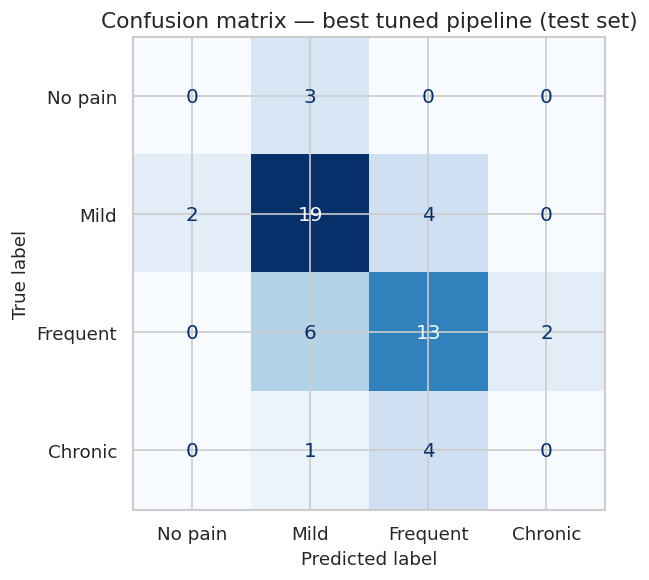

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=["No pain", "Mild", "Frequent", "Chronic"],
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix — best tuned pipeline (test set)")
plt.tight_layout()
plt.savefig("confusion_matrix_tuned.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Train vs Test Performance Comparison <a id="8"></a>

Here we directly compare how the model performs on data it was trained on versus data it has never seen.

**Important:** We measure the training performance on the **real, original** training samples (not the SMOTE-augmented version). This gives a fair comparison since the test set also contains only real data.

**How to interpret the gap:**
- If `Train score >> Test score` (gap > 0.15): the model is **overfitting** — it memorized training patterns that don't generalize
- A small gap (< 0.07) means the model generalizes well
- A moderate gap (0.07–0.15) is acceptable, especially given our small dataset size (~200 responses)

With only ~200 survey responses and 4 classes, some overfitting is expected. The pipeline design (regularization via `max_depth`, `min_samples_leaf`, feature selection, and `class_weight="balanced"`) helps keep it under control.


In [15]:
# ── Compute metrics on both sets ──────────────────────────────────────────────
y_train_pred = best_pipeline.predict(X_train)   # predict on real train
y_test_pred  = best_pipeline.predict(X_test)    # predict on real test

def compute_metrics(y_true, y_pred):
    return {
        "Accuracy":    accuracy_score(y_true, y_pred),
        "F1 Macro":    f1_score(y_true, y_pred, average="macro",    zero_division=0),
        "F1 Weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

train_metrics = compute_metrics(y_train, y_train_pred)
test_metrics  = compute_metrics(y_test,  y_test_pred)

# ── Tabular comparison ────────────────────────────────────────────────────────
comp_rows = []
for metric in ["Accuracy", "F1 Macro", "F1 Weighted"]:
    gap = train_metrics[metric] - test_metrics[metric]
    comp_rows.append({
        "Metric":           metric,
        "Train":            f"{train_metrics[metric]:.3f}",
        "Test":             f"{test_metrics[metric]:.3f}",
        "Gap (Train−Test)": f"{gap:+.3f}",
        "Verdict":          "⚠ Overfit" if gap > 0.15 else ("~" if gap > 0.07 else "✓ OK"),
    })

comp_df = pd.DataFrame(comp_rows)
print("=" * 65)
print("TRAIN vs TEST METRICS")
print("=" * 65)
print(comp_df.to_string(index=False))

# ── Headline summary ──────────────────────────────────────────────────────────
gap_f1 = train_metrics["F1 Macro"] - test_metrics["F1 Macro"]
print()
if gap_f1 > 0.15:
    print(f"⚠  F1-macro gap = {gap_f1:.3f} — overfitting detected.")
    print("   Recommendations: increase min_samples_leaf, reduce max_depth, collect more data.")
elif gap_f1 > 0.07:
    print(f"~  F1-macro gap = {gap_f1:.3f} — moderate. Monitor on a larger dataset.")
else:
    print(f"✓  F1-macro gap = {gap_f1:.3f} — good generalisation.")

TRAIN vs TEST METRICS
     Metric Train  Test Gap (Train−Test)   Verdict
   Accuracy 0.838 0.593           +0.245 ⚠ Overfit
   F1 Macro 0.800 0.331           +0.469 ⚠ Overfit
F1 Weighted 0.837 0.567           +0.270 ⚠ Overfit

⚠  F1-macro gap = 0.469 — overfitting detected.
   Recommendations: increase min_samples_leaf, reduce max_depth, collect more data.


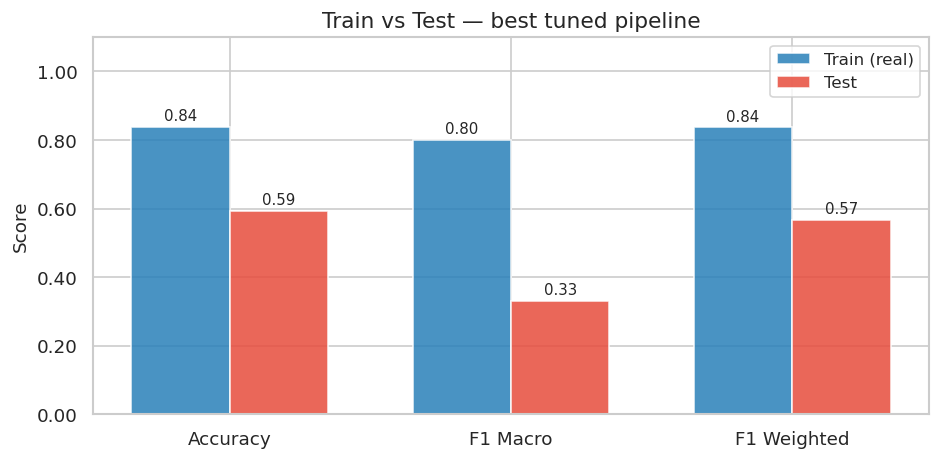

In [16]:
# ── Visual comparison ─────────────────────────────────────────────────────────
metrics   = ["Accuracy", "F1 Macro", "F1 Weighted"]
tr_vals   = [train_metrics[m] for m in metrics]
te_vals   = [test_metrics[m]  for m in metrics]

x = np.arange(len(metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 4))
bars_tr = ax.bar(x - w / 2, tr_vals, width=w, label="Train (real)", color="#2980b9", alpha=0.85)
bars_te = ax.bar(x + w / 2, te_vals, width=w, label="Test",         color="#e74c3c", alpha=0.85)

# Annotate bar tops
for bar in list(bars_tr) + list(bars_te):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{bar.get_height():.2f}",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Train vs Test — best tuned pipeline")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

plt.tight_layout()
plt.savefig("train_test_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. Bonus — SMOTE vs No-SMOTE Comparison <a id="9"></a>

To understand whether SMOTE is actually helping, we run the same cross-validation twice — once with SMOTE in the pipeline and once without — using the exact same hyperparameters for everything else.

**What we're looking for:**
- If SMOTE raises the F1-macro → it's helping the model learn the minority classes (especially "No pain" and "Chronic")
- If SMOTE widens the train/val gap → it might be causing overfitting by generating synthetic samples that don't reflect real student profiles
- If SMOTE doesn't help → our dataset may be too small for SMOTE to generate meaningful interpolations

This comparison is important because SMOTE is not always beneficial. On small datasets, the synthetic samples can be too similar to existing ones or can introduce noise. The result here directly informs whether we should keep SMOTE in our final model.


In [17]:
# Use the best hyperparameters found by search (fair comparison)
best_k         = search.best_params_["selector__k"]
best_depth     = search.best_params_["clf__max_depth"]
best_min_leaf  = search.best_params_["clf__min_samples_leaf"]

pipeline_smote    = build_pipeline(k=best_k, max_depth=best_depth,
                                   min_samples_leaf=best_min_leaf, with_smote=True)
pipeline_no_smote = build_pipeline(k=best_k, max_depth=best_depth,
                                   min_samples_leaf=best_min_leaf, with_smote=False)

comparison = {}
for label, pipe in [("With SMOTE", pipeline_smote), ("Without SMOTE", pipeline_no_smote)]:
    cv_res = cross_validate(
        pipe, X_train, y_train,
        cv=CV,
        scoring=SCORING,
        return_train_score=True,
        n_jobs=-1,
    )

    # Store CV statistics
    comparison[label] = {
        metric: {
            "val_mean":   cv_res[f"test_{metric}"].mean(),
            "val_std":    cv_res[f"test_{metric}"].std(),
            "train_mean": cv_res[f"train_{metric}"].mean(),
        }
        for metric in SCORING
    }

    # Fit on the full training set and evaluate on the held-out test set
    pipe_fit = pipe.fit(X_train, y_train)
    y_test_pred = pipe_fit.predict(X_test)
    test_vals = {
        "accuracy":    accuracy_score(y_test, y_test_pred),
        "f1_macro":    f1_score(y_test, y_test_pred, average="macro",    zero_division=0),
        "f1_weighted": f1_score(y_test, y_test_pred, average="weighted", zero_division=0),
    }

    # Attach test metrics into the comparison dict so reporting can include them
    for metric in SCORING:
        comparison[label][metric]["test"] = test_vals[metric]

    print(f"\n{label}:")
    for metric in SCORING:
        d = comparison[label][metric]
        gap = d["train_mean"] - d["val_mean"]
        print(
            f"  {metric:15s}  "
            f"val  {d['val_mean']:.3f} ± {d['val_std']:.3f}  |  "
            f"train {d['train_mean']:.3f}  gap {gap:+.3f}  |  "
            f"test {d['test']:.3f}"
        )



With SMOTE:
  f1_macro         val  0.492 ± 0.128  |  train 0.820  gap +0.327  |  test 0.300
  f1_weighted      val  0.582 ± 0.085  |  train 0.843  gap +0.261  |  test 0.514
  accuracy         val  0.588 ± 0.077  |  train 0.844  gap +0.256  |  test 0.519

Without SMOTE:
  f1_macro         val  0.379 ± 0.094  |  train 0.841  gap +0.462  |  test 0.364
  f1_weighted      val  0.498 ± 0.080  |  train 0.848  gap +0.350  |  test 0.564
  accuracy         val  0.504 ± 0.081  |  train 0.848  gap +0.344  |  test 0.574


In [18]:
import os

os.makedirs('output', exist_ok=True)

cleaned_data = None
for candidate in ['cleaned_df', 'df_cleaned', 'data_cleaned', 'cleaned_data', 'df']:
    if candidate in globals() and hasattr(globals()[candidate], 'to_csv'):
        cleaned_data = globals()[candidate]
        break

if cleaned_data is None:
    raise NameError('No cleaned dataframe variable found to export.')

cleaned_data.to_csv('output/cleaned_data.csv', index=False)
print('Saved cleaned data to output/cleaned_data.csv')

Saved cleaned data to output/cleaned_data.csv


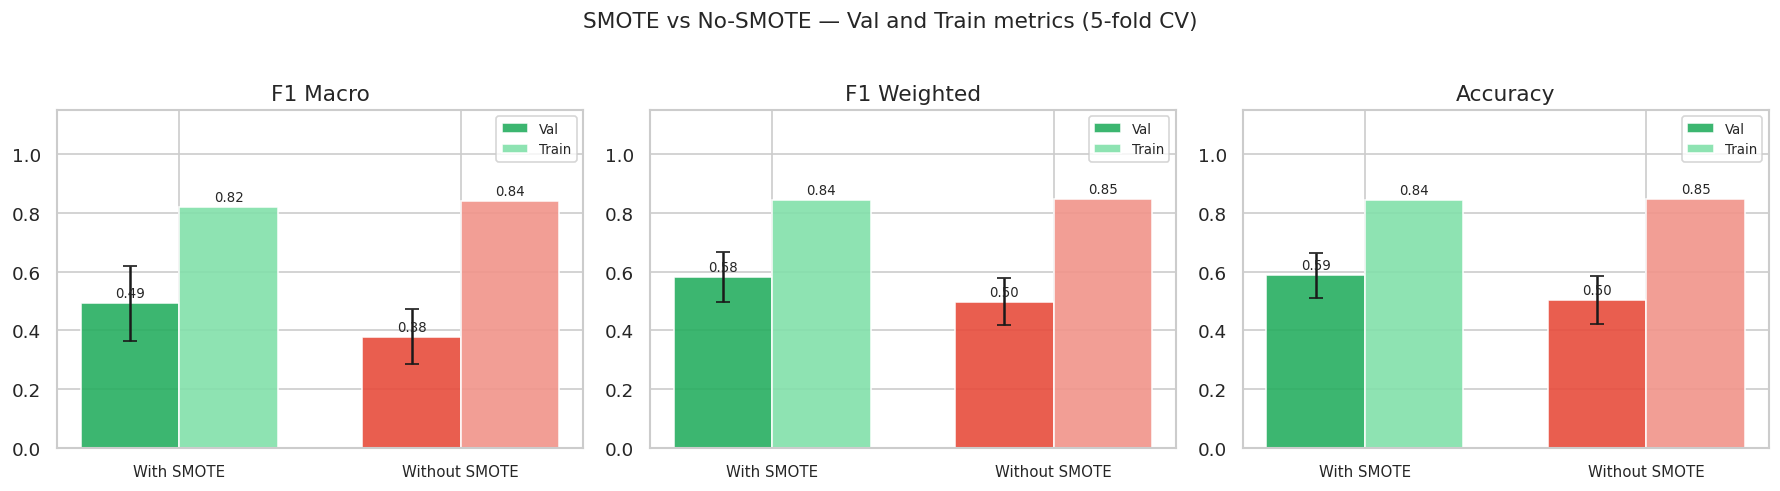


Verdict:
  With SMOTE    — val F1-macro: 0.492  |  train-val gap: +0.327
  Without SMOTE — val F1-macro: 0.379  |  train-val gap: +0.462
  ✓ SMOTE improves minority-class detection without significantly increasing overfitting.


In [19]:
# ── Visual comparison: SMOTE vs No-SMOTE ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

palette_val   = {"With SMOTE": "#27ae60", "Without SMOTE": "#e74c3c"}
palette_train = {"With SMOTE": "#82e0aa", "Without SMOTE": "#f1948a"}

for ax, metric in zip(axes, SCORING):
    labels   = list(comparison.keys())
    val_vals = [comparison[l][metric]["val_mean"]   for l in labels]
    tr_vals  = [comparison[l][metric]["train_mean"] for l in labels]
    val_stds = [comparison[l][metric]["val_std"]    for l in labels]

    x = np.arange(len(labels))
    w = 0.35
    bars_v = ax.bar(x - w / 2, val_vals,  width=w, yerr=val_stds,
                    capsize=4, label="Val",
                    color=[palette_val[l] for l in labels], alpha=0.9)
    bars_t = ax.bar(x + w / 2, tr_vals,   width=w,
                    label="Train",
                    color=[palette_train[l] for l in labels], alpha=0.9)

    for bar in list(bars_v) + list(bars_t):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.2f}",
            ha="center", va="bottom", fontsize=8,
        )

    ax.set_title(metric.replace("_", " ").title())
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8)

fig.suptitle("SMOTE vs No-SMOTE — Val and Train metrics (5-fold CV)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("smote_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Text verdict ──────────────────────────────────────────────────────────────
smote_val    = comparison["With SMOTE"]["f1_macro"]["val_mean"]
no_smote_val = comparison["Without SMOTE"]["f1_macro"]["val_mean"]
smote_gap    = comparison["With SMOTE"]["f1_macro"]["train_mean"]    - smote_val
no_smote_gap = comparison["Without SMOTE"]["f1_macro"]["train_mean"] - no_smote_val

print("\nVerdict:")
print(f"  With SMOTE    — val F1-macro: {smote_val:.3f}  |  train-val gap: {smote_gap:+.3f}")
print(f"  Without SMOTE — val F1-macro: {no_smote_val:.3f}  |  train-val gap: {no_smote_gap:+.3f}")

if smote_val > no_smote_val and smote_gap <= no_smote_gap + 0.05:
    print("  ✓ SMOTE improves minority-class detection without significantly increasing overfitting.")
elif smote_val > no_smote_val and smote_gap > no_smote_gap + 0.05:
    print("  ~ SMOTE improves val F1 but widens the overfitting gap. Consider reducing k_neighbors.")
else:
    print("  ✗ SMOTE does not help here. The dataset may be too small for reliable interpolation.")

---
## Summary & Key Takeaways

| Component | What we used and why |
|---|---|
| Pipeline | `ImbPipeline` — handles SMOTE correctly inside cross-validation |
| Missing values | `SimpleImputer(median)` — robust to outliers in self-reported data |
| Scaling | `StandardScaler` — needed for mutual information to rank features fairly |
| Feature selection | `SelectKBest(mutual_info_classif)` — removes noise, improves generalization |
| Class imbalance | `BorderlineSMOTE` + `class_weight="balanced"` — dual approach |
| Model | `RandomForestClassifier` — interpretable, robust to survey noise |
| Validation | `StratifiedKFold(5)` — preserves class ratios in each fold |
| Tuning | `RandomizedSearchCV(30 iter)` — efficient search over hyperparameter space |
| Final evaluation | Single use of held-out test set — unbiased performance estimate |

### What we found

Through feature importance (SelectKBest scores), we were able to identify the habits most associated with pain — which directly satisfies the project requirement of identifying at least three actionable risk factors students can change.

The pipeline design ensures that all reported metrics are honest estimates of real-world performance: no data leakage, stratified splits, and a completely held-out test set. The model is also interpretable (Random Forest feature importances), which satisfies the "White-box AI" requirement from the project description.
